              ***Nescafe vs. Starbucks: Strategic Market Analysis***
    
 *Project Objective*: This analysis identifies key demographic strengths and preferential gaps for Nescafe in comparison to Starbucks. By analyzing "Affinity Indices", we aim to pinpoint specific growth opportunities and risk segments.

*Data Source*: Consumer Characteristics and Preferential Data

*Key Metric*: Index score(100 = Market Average)

In [ ]:
import pandas as pd
import numpy as np

In [ ]:
df = pd.read_excel("/content/Consulting Case Study (2).xlsx", sheet_name=None)

In [ ]:
df_char = df['Consumers Characteristics']
df_pref = df['Consumers Preferential Data']

In [ ]:
df_char.head()

,Unnamed: 0,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Demographic Set,Population Characteristics,Element,% of Nescafe Shoppers,% of All Shoppers,Index,% of Starbucks Shoppers,% of All Shoppers,Index
3,Traditional Demographics,Age (Brackets),18-20,0.01,0.005,204,0.005,0.005,102
4,Traditional Demographics,Age (Brackets),21-24,0.048,0.033,145,0.029,0.033,87


**Data Processing & Cleaning**
The raw dataset contains merged headers and several empty rows. In this section, we will:
*   Remove structural noise (empty rows).
*   Standardize column headers for both Nescafe and Starbucks datasets
*   Will check the datatypes and if required will change necessary datatypes of numeric columns

In [ ]:
df_char = df_char.iloc[2:].reset_index(drop=True)
df_char.columns=df_char.iloc[0]
df_char=df_char.iloc[1:].reset_index(drop=True)

In [ ]:
df_char.head()

,Demographic Set,Population Characteristics,Element,% of Nescafe Shoppers,% of All Shoppers,Index,% of Starbucks Shoppers,% of All Shoppers,Index
0,Traditional Demographics,Age (Brackets),18-20,0.01,0.005,204,0.005,0.005,102
1,Traditional Demographics,Age (Brackets),21-24,0.048,0.033,145,0.029,0.033,87
2,Traditional Demographics,Age (Brackets),25-34,0.199,0.156,127,0.162,0.156,104
3,Traditional Demographics,Age (Brackets),35-44,0.232,0.168,138,0.189,0.168,113
4,Traditional Demographics,Age (Brackets),45-54,0.179,0.158,113,0.178,0.158,113


In [ ]:
df_char.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 77 entries, 0 to 76
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   Demographic Set             77 non-null     object
 1   Population Characteristics  77 non-null     object
 2   Element                     77 non-null     object
 3   % of Nescafe Shoppers       77 non-null     object
 4   % of All Shoppers           77 non-null     object
 5   Index                       77 non-null     object
 6   % of Starbucks Shoppers     77 non-null     object
 7   % of All Shoppers           77 non-null     object
 8   Index                       77 non-null     object
dtypes: object(9)
memory usage: 5.5+ KB


In [ ]:
# Renaming columns for better understanding as two columns have same column names
df_char.columns = ['Demographic_Set', 'Characteristics', 'Element', 'Nescafe_Pct', 'All_Shoppers_Pct_N', 'Nescafe_Index', 'Starbucks_Pct', 'All_Shoppers_Pct_S', 'Starbucks_Index']

In [ ]:
# changing the data type of numeric columns
cols_to_fix = ['Nescafe_Pct', 'All_Shoppers_Pct_N', 'Nescafe_Index', 'Starbucks_Pct', 'All_Shoppers_Pct_S', 'Starbucks_Index']
df_char[cols_to_fix] = df_char[cols_to_fix].apply(pd.to_numeric, errors='coerce')

In [ ]:
df_char.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 77 entries, 0 to 76
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Demographic_Set     77 non-null     object 
 1   Characteristics     77 non-null     object 
 2   Element             77 non-null     object 
 3   Nescafe_Pct         75 non-null     float64
 4   All_Shoppers_Pct_N  75 non-null     float64
 5   Nescafe_Index       75 non-null     float64
 6   Starbucks_Pct       75 non-null     float64
 7   All_Shoppers_Pct_S  75 non-null     float64
 8   Starbucks_Index     75 non-null     float64
dtypes: float64(6), object(3)
memory usage: 5.5+ KB


In [ ]:
df_char.head()

,Demographic_Set,Characteristics,Element,Nescafe_Pct,All_Shoppers_Pct_N,Nescafe_Index,Starbucks_Pct,All_Shoppers_Pct_S,Starbucks_Index
0,Traditional Demographics,Age (Brackets),18-20,0.010,0.005,204.0,0.005,0.005,102.0
1,Traditional Demographics,Age (Brackets),21-24,0.048,0.033,145.0,0.029,0.033,87.0
2,Traditional Demographics,Age (Brackets),25-34,0.199,0.156,127.0,0.162,0.156,104.0
3,Traditional Demographics,Age (Brackets),35-44,0.232,0.168,138.0,0.189,0.168,113.0
4,Traditional Demographics,Age (Brackets),45-54,0.179,0.158,113.0,0.178,0.158,113.0


In [ ]:
print("Missing values per column:")
print(df_char.isnull().sum())

Missing values per column:
Demographic_Set       0
Characteristics       0
Element               0
Nescafe_Pct           2
All_Shoppers_Pct_N    2
Nescafe_Index         2
Starbucks_Pct         2
All_Shoppers_Pct_S    2
Starbucks_Index       2
dtype: int64


In [ ]:
df_char = df_char.dropna(subset=['Nescafe_Index'])
print(df_char.isnull().sum())

Demographic_Set       0
Characteristics       0
Element               0
Nescafe_Pct           0
All_Shoppers_Pct_N    0
Nescafe_Index         0
Starbucks_Pct         0
All_Shoppers_Pct_S    0
Starbucks_Index       0
dtype: int64


In [ ]:
# Feature Engineering

# --- 1. Calculation of Index Differential ---
df_char['Index_Gap'] = df_char['Nescafe_Index'] - df_char['Starbucks_Index']

# --- 2. Function for Segment Status ---
def get_segment_status(index):
  if index > 110:
    return 'Core (Over-Index)'
  elif index < 90:
    return 'Risk (Under-Index)'
  else:
    return 'Average'

df_char['Nescafe_Status'] = df_char['Nescafe_Index'].apply(get_segment_status)
df_char['Starbucks_Status'] = df_char['Starbucks_Index'].apply(get_segment_status)

df_char.head()

,Demographic_Set,Characteristics,Element,Nescafe_Pct,All_Shoppers_Pct_N,Nescafe_Index,Starbucks_Pct,All_Shoppers_Pct_S,Starbucks_Index,Index_Gap,Nescafe_Status,Starbucks_Status
0,Traditional Demographics,Age (Brackets),18-20,0.010,0.005,204.0,0.005,0.005,102.0,102.0,Core (Over-Index),Average
1,Traditional Demographics,Age (Brackets),21-24,0.048,0.033,145.0,0.029,0.033,87.0,58.0,Core (Over-Index),Risk (Under-Index)
2,Traditional Demographics,Age (Brackets),25-34,0.199,0.156,127.0,0.162,0.156,104.0,23.0,Core (Over-Index),Average
3,Traditional Demographics,Age (Brackets),35-44,0.232,0.168,138.0,0.189,0.168,113.0,25.0,Core (Over-Index),Core (Over-Index)
4,Traditional Demographics,Age (Brackets),45-54,0.179,0.158,113.0,0.178,0.158,113.0,0.0,Core (Over-Index),Core (Over-Index)


**Demographic Profiling (The "Who")**

We will evaluate how Nescafe performs across traditional demographics like Age, Lifestage, Income etc. An index significantly above 100 indicates a "Core" strength, while an index below 100 indicates a "Risk" segment.

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

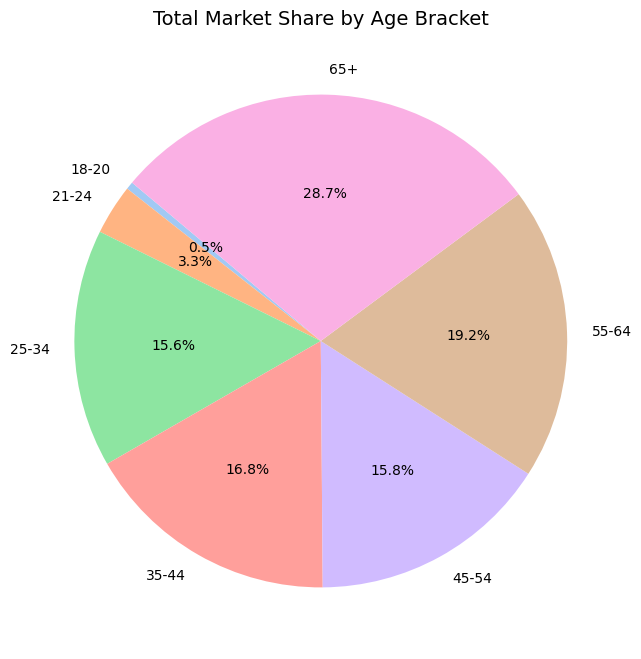

In [ ]:
# --- UNIVARIATE ANALYSIS ---
age_data = df_char[df_char['Characteristics'] == 'Age (Brackets)']

plt.figure(figsize=(8, 8))
plt.pie(age_data['All_Shoppers_Pct_N'],
        labels=age_data['Element'],
        autopct='%1.1f%%',
        startangle=140,
        colors=sns.color_palette('pastel'))
plt.title('Total Market Share by Age Bracket', fontsize=14)
plt.show()

In [ ]:
print(df_char['Characteristics'].unique())

['Age (Brackets)' 'Age (Generation)' 'Education' 'Employment' 'Ethnicity'
 'Household Size' 'Income $' 'Income Bucket' 'Marital Status'
 'Amazon Prime' 'Lifestage' 'Lifestyle']


In [ ]:
print(df_char['Characteristics'].value_counts())

Characteristics
Lifestage           10
Employment           9
Lifestyle            9
Education            8
Household Size       7
Age (Brackets)       7
Income $             7
Marital Status       6
Age (Generation)     4
Income Bucket        3
Amazon Prime         3
Ethnicity            2
Name: count, dtype: int64


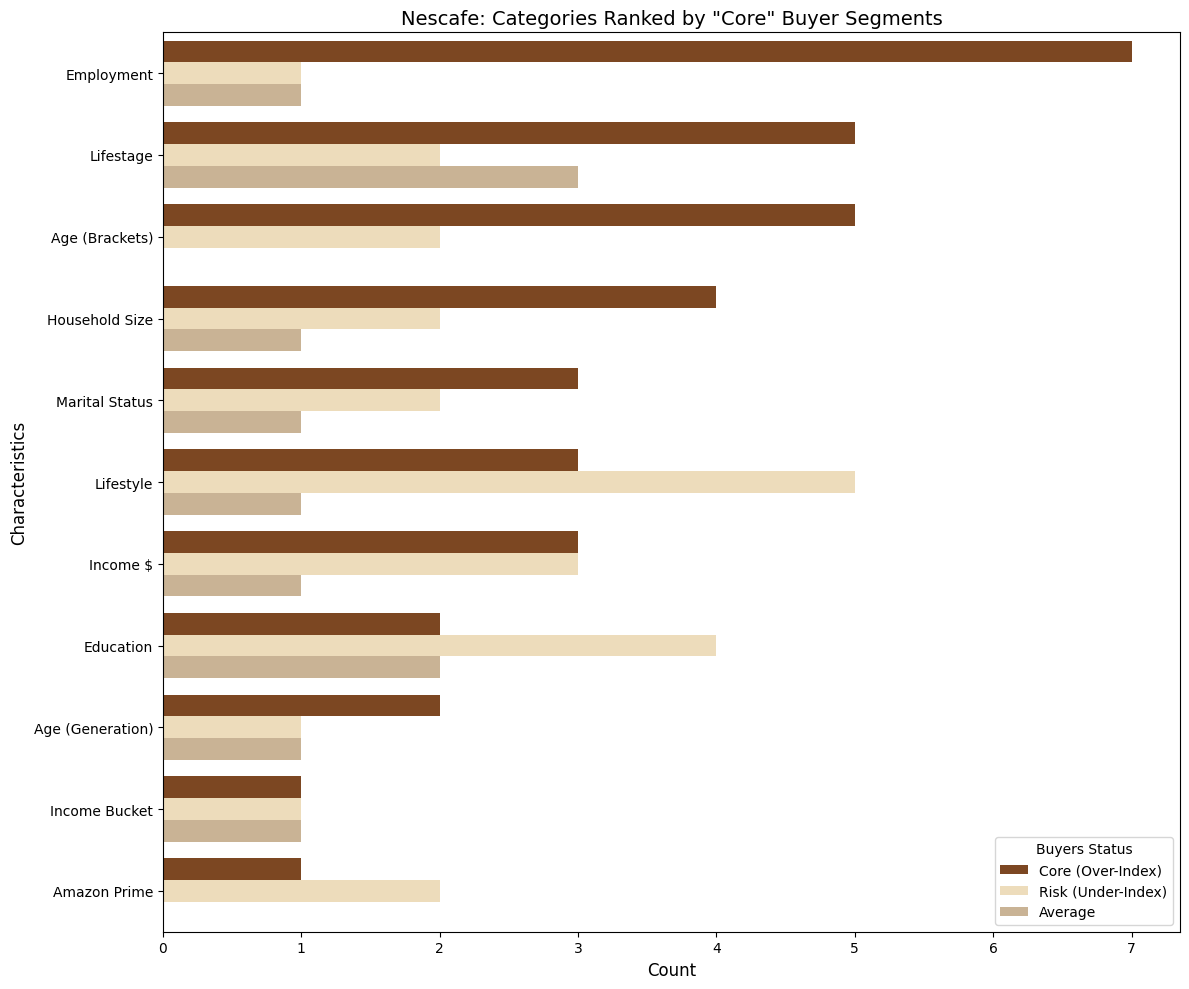

In [ ]:
order = df_char[df_char['Nescafe_Status'] == 'Core (Over-Index)']['Characteristics'].value_counts().index
plt.figure(figsize=(12, 10))
sns.countplot(data=df_char, y='Characteristics', hue='Nescafe_Status', order=order, palette={'Core (Over-Index)': 'saddlebrown', 'Average': 'tan', 'Risk (Under-Index)': 'wheat'})
plt.xlabel('Count', fontsize=12)
plt.ylabel('Characteristics', fontsize=12)
plt.title('Nescafe: Categories Ranked by "Core" Buyer Segments', fontsize=14)
plt.legend(title='Buyers Status', loc='lower right')
plt.tight_layout()
plt.show()


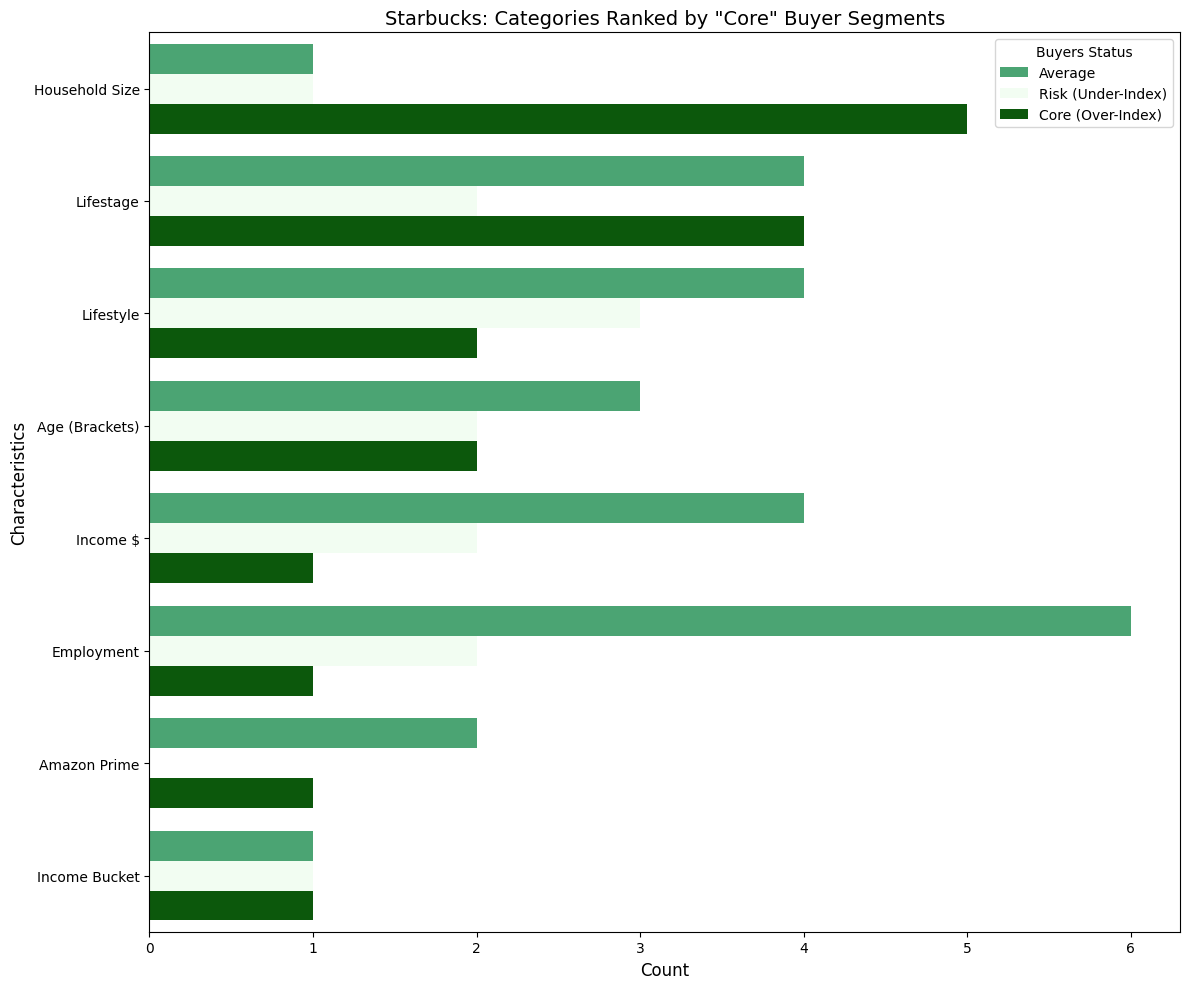

In [ ]:
order = df_char[df_char['Starbucks_Status'] == 'Core (Over-Index)']['Characteristics'].value_counts().index
plt.figure(figsize=(12, 10))
sns.countplot(data=df_char, y='Characteristics', hue='Starbucks_Status',order=order, palette={'Core (Over-Index)': 'darkgreen', 'Average': 'mediumseagreen', 'Risk (Under-Index)': 'honeydew'})
plt.xlabel('Count', fontsize=12)
plt.ylabel('Characteristics', fontsize=12)
plt.title('Starbucks: Categories Ranked by "Core" Buyer Segments', fontsize=14)
plt.legend(title='Buyers Status', loc='upper right')
plt.tight_layout()
plt.show()

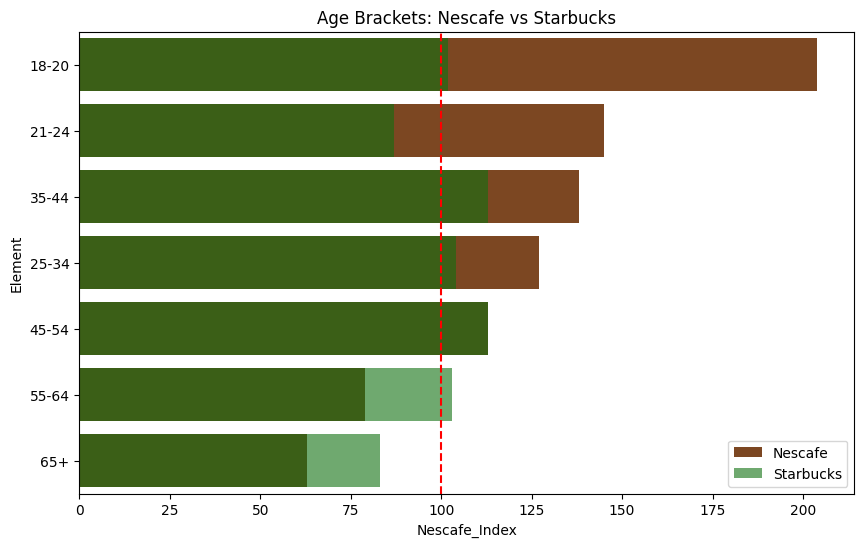

In [ ]:
age_data = df_char[df_char['Characteristics'] == 'Age (Brackets)']
age_data = age_data.sort_values('Nescafe_Index', ascending=False)
plt.figure(figsize=(10, 6))
sns.barplot(data=age_data, x='Nescafe_Index', y='Element', color='saddlebrown', label='Nescafe')
sns.barplot(data=age_data, x='Starbucks_Index', y='Element', color='green', alpha=0.6, label='Starbucks')
plt.axvline(100, color='red', linestyle='--')
plt.title('Age Brackets: Nescafe vs Starbucks')
plt.legend()
plt.show()

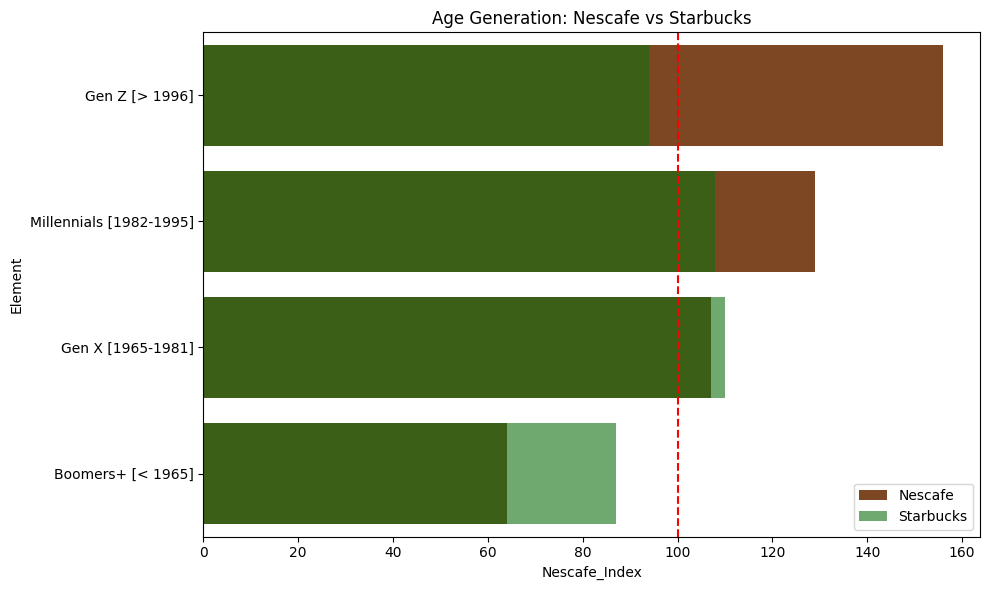

In [ ]:
age_gen_data = df_char[df_char['Characteristics'] == 'Age (Generation)']
age_gen_data = age_gen_data.sort_values('Nescafe_Index', ascending=False)
plt.figure(figsize=(10, 6))
sns.barplot(data=age_gen_data, x='Nescafe_Index', y='Element', color='saddlebrown', label='Nescafe')
sns.barplot(data=age_gen_data, x='Starbucks_Index', y='Element', color='green', alpha=0.6, label='Starbucks')
plt.axvline(100, color='red', linestyle='--')
plt.title('Age Generation: Nescafe vs Starbucks')
plt.tight_layout()
plt.legend()
plt.show()

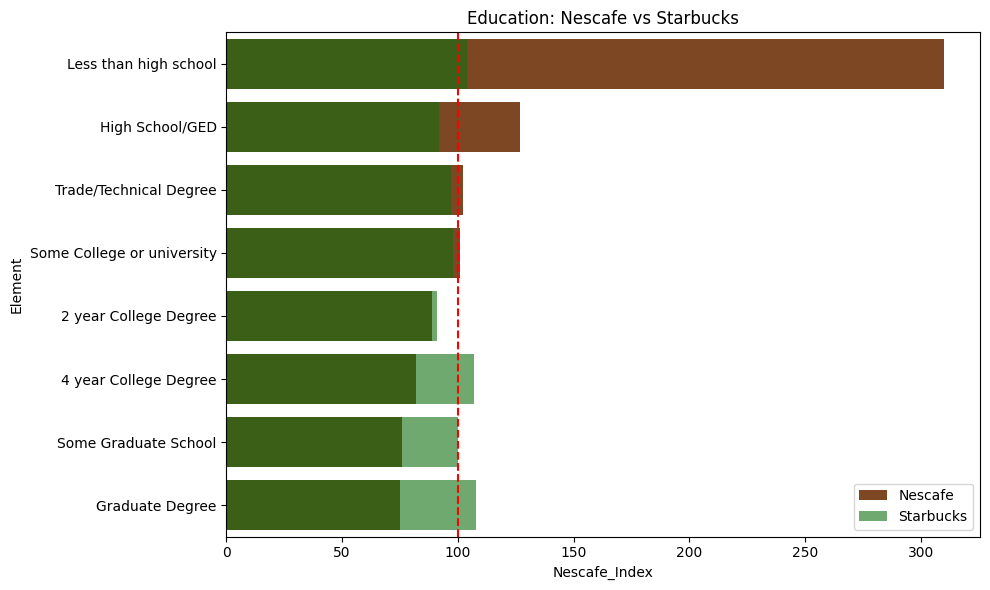

In [ ]:
edu_data = df_char[df_char['Characteristics'] == 'Education']
edu_data = edu_data.sort_values('Nescafe_Index', ascending=False)
plt.figure(figsize=(10, 6))
sns.barplot(data=edu_data, x='Nescafe_Index', y='Element', color='saddlebrown', label='Nescafe')
sns.barplot(data=edu_data, x='Starbucks_Index', y='Element', color='green', alpha=0.6, label='Starbucks')
plt.axvline(100, color='red', linestyle='--')
plt.title('Education: Nescafe vs Starbucks')
plt.tight_layout()
plt.legend()
plt.show()

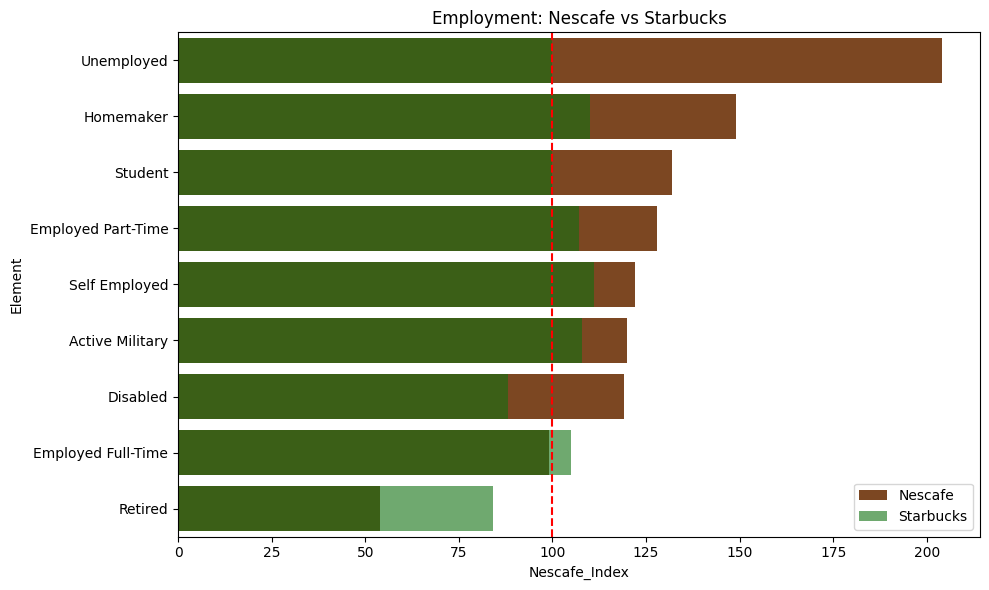

In [ ]:
empl_data = df_char[df_char['Characteristics'] == 'Employment']
empl_data = empl_data.sort_values('Nescafe_Index', ascending=False)
plt.figure(figsize=(10, 6))
sns.barplot(data=empl_data, x='Nescafe_Index', y='Element', color='saddlebrown', label='Nescafe')
sns.barplot(data=empl_data, x='Starbucks_Index', y='Element', color='green', alpha=0.6, label='Starbucks')
plt.title('Employment: Nescafe vs Starbucks')
plt.axvline(100, color='red', linestyle='--')
plt.tight_layout()
plt.legend()
plt.show()

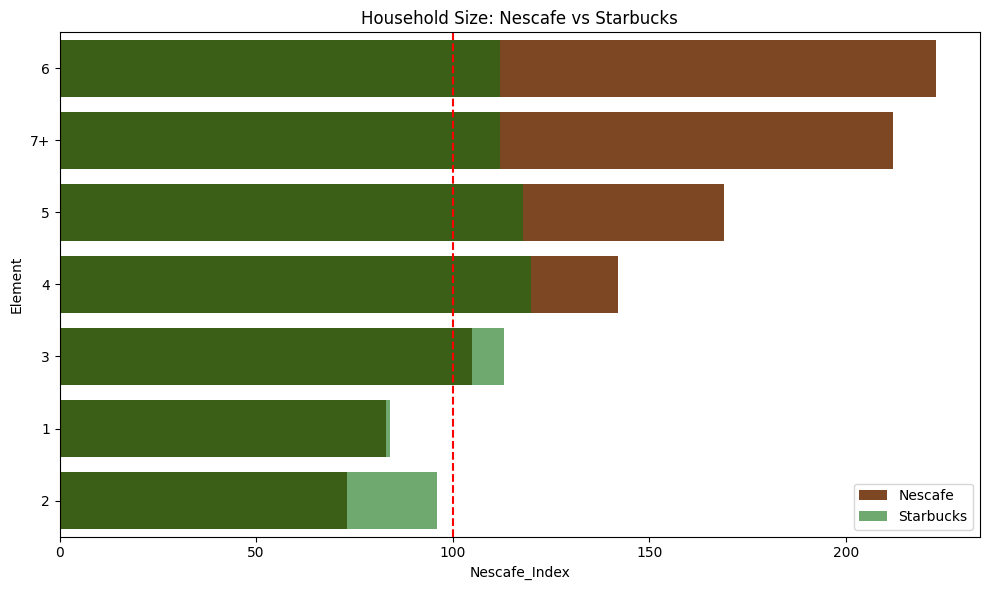

In [ ]:
household_size_data = df_char[df_char['Characteristics'] == 'Household Size']
household_size_data = household_size_data.sort_values('Nescafe_Index', ascending=False)
plt.figure(figsize=(10, 6))
sns.barplot(data=household_size_data, x='Nescafe_Index', y='Element', color='saddlebrown', label='Nescafe')
sns.barplot(data=household_size_data, x='Starbucks_Index', y='Element', color='green', alpha=0.6, label='Starbucks')
plt.axvline(100, color='red', linestyle='--')
plt.title('Household Size: Nescafe vs Starbucks')
plt.tight_layout()
plt.legend()
plt.show()

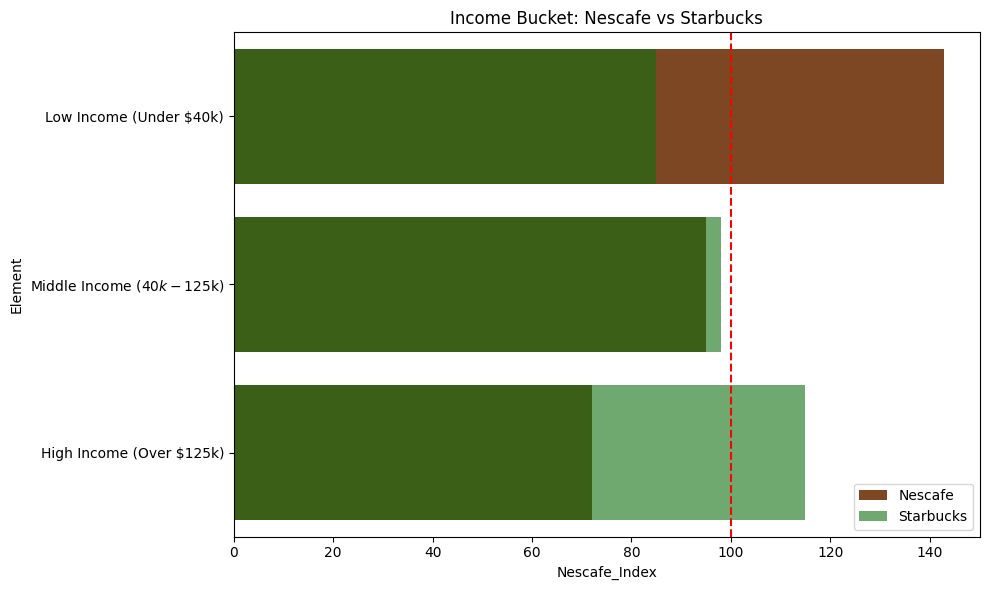

In [ ]:
inc_bucket_data = df_char[df_char['Characteristics'] == 'Income Bucket']
inc_bucket_data = inc_bucket_data.sort_values('Nescafe_Index', ascending=False)
plt.figure(figsize=(10, 6))
sns.barplot(data=inc_bucket_data, x='Nescafe_Index', y='Element', color='saddlebrown', label='Nescafe')
sns.barplot(data=inc_bucket_data, x='Starbucks_Index', y='Element', color='green', alpha=0.6, label='Starbucks')
plt.axvline(100, color='red', linestyle='--')
plt.title('Income Bucket: Nescafe vs Starbucks')
plt.tight_layout()
plt.legend()
plt.show()

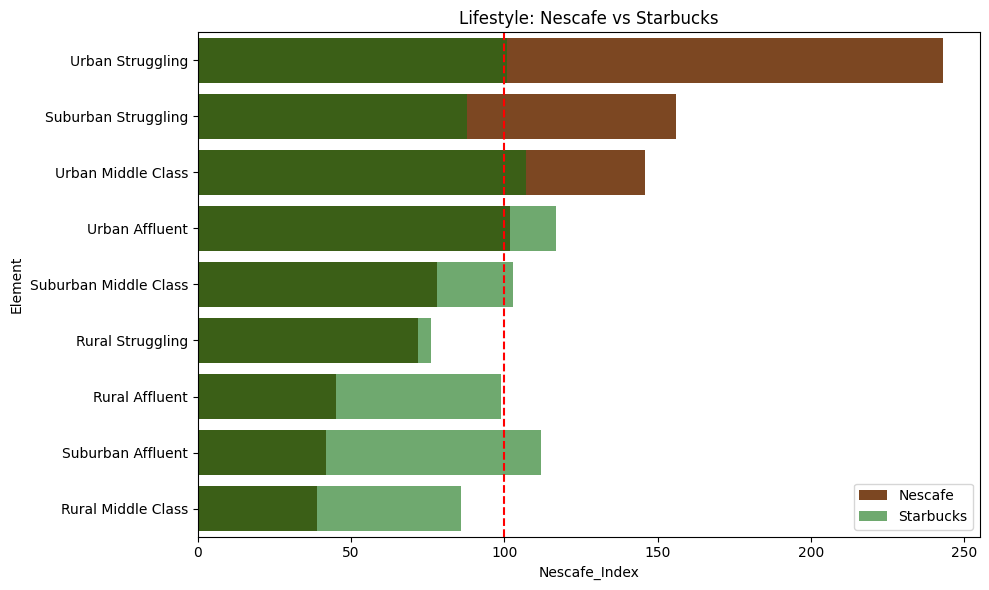

In [ ]:
lifestyle_data = df_char[df_char['Characteristics'] == 'Lifestyle']
lifestyle_data = lifestyle_data.sort_values('Nescafe_Index', ascending=False)
plt.figure(figsize=(10, 6))
sns.barplot(data=lifestyle_data, x='Nescafe_Index', y='Element', color='saddlebrown', label='Nescafe')
sns.barplot(data=lifestyle_data, x='Starbucks_Index', y='Element', color='green', alpha=0.6, label='Starbucks')
plt.axvline(100, color='red', linestyle='--')
plt.title('Lifestyle: Nescafe vs Starbucks')
plt.tight_layout()
plt.legend()
plt.show()

/tmp/ipykernel_459/4007226685.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


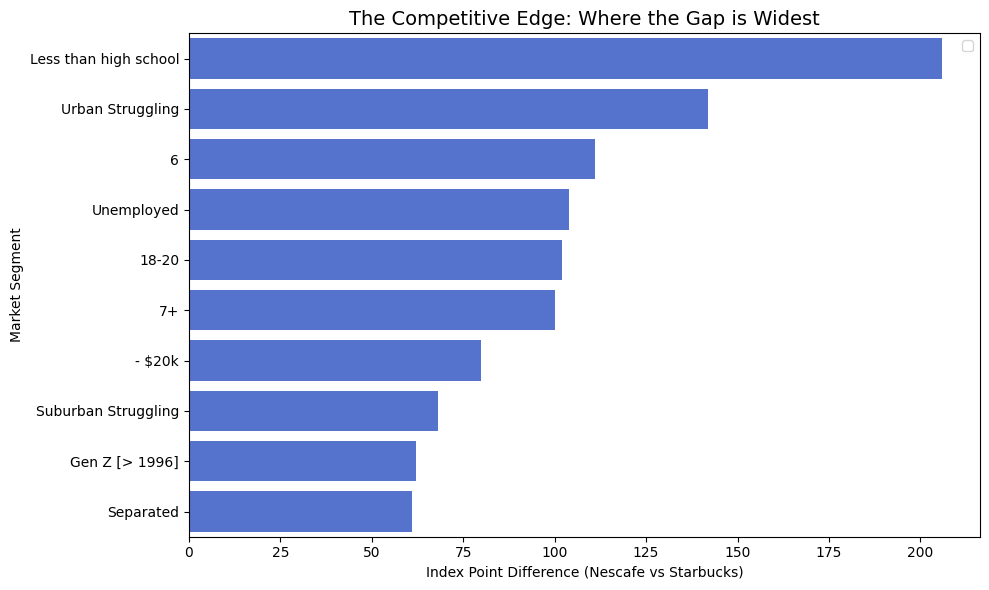

In [ ]:
gap_data = df_char.sort_values('Index_Gap', ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(data=gap_data, x='Index_Gap', y='Element', color='royalblue')
plt.title('The Competitive Edge: Where the Gap is Widest', fontsize=14)
plt.xlabel('Index Point Difference (Nescafe vs Starbucks)')
plt.ylabel('Market Segment')
plt.tight_layout()
plt.legend()
plt.show()

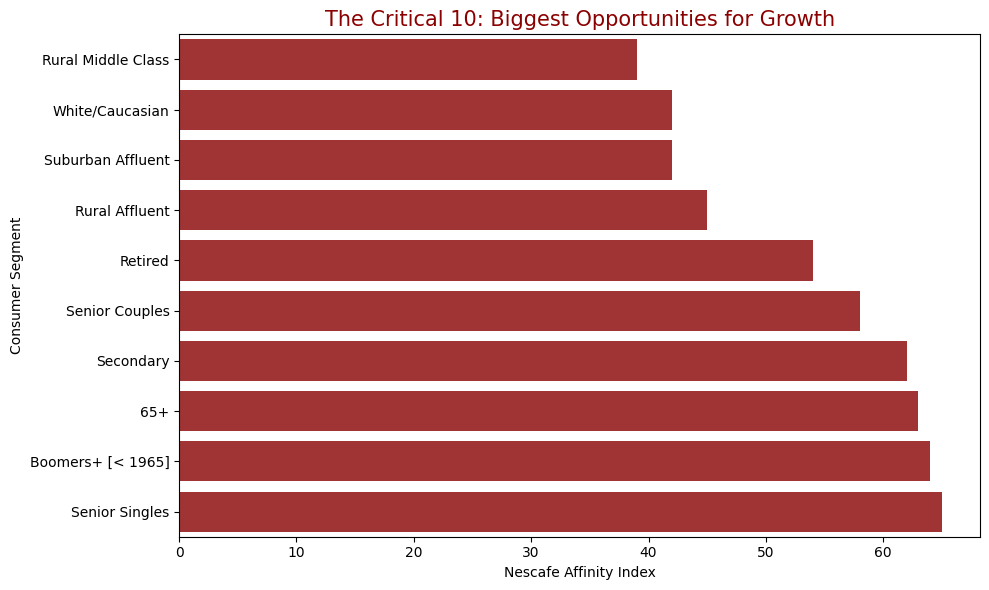

In [ ]:
# --- Critical Action List ---
nescafe_risks = df_char.sort_values('Nescafe_Index', ascending=True).head(10)
plt.figure(figsize=(10, 6))
ax = sns.barplot(data=nescafe_risks, x='Nescafe_Index', y='Element', color='firebrick')
plt.title('The Critical 10: Biggest Opportunities for Growth', fontsize=15, color='darkred')
plt.xlabel('Nescafe Affinity Index')
plt.ylabel('Consumer Segment')
plt.tight_layout()
plt.show()

In [ ]:
df_pref.head()

,Unnamed: 0,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Consumer's Preference,Header,Survey Question,Response,% of Starbucks Shoppers,% of All Shoppers,Index,% of Nescafe Shoppers,% of All Shoppers,Index
3,Advertising,Exposed Touchpoints,"How do you learn about products, services and ...",Online Web,0.571,0.582,98,0.463,0.582,80
4,Advertising,Exposed Touchpoints,"How do you learn about products, services and ...",Online Mobile Device,0.567,0.57,99,0.19,0.57,33


In [ ]:
df_pref = df_pref.iloc[2:].reset_index(drop=True)
df_pref.columns=df_pref.iloc[0]
df_pref=df_pref.iloc[1:].reset_index(drop=True)

In [ ]:
df_pref.head()

,Consumer's Preference,Header,Survey Question,Response,% of Starbucks Shoppers,% of All Shoppers,Index,% of Nescafe Shoppers,% of All Shoppers,Index
0,Advertising,Exposed Touchpoints,"How do you learn about products, services and ...",Online Web,0.571,0.582,98,0.463,0.582,80
1,Advertising,Exposed Touchpoints,"How do you learn about products, services and ...",Online Mobile Device,0.567,0.57,99,0.19,0.57,33
2,Advertising,Exposed Touchpoints,"How do you learn about products, services and ...",Television,0.491,0.508,97,0.516,0.508,102
3,Advertising,Exposed Touchpoints,"How do you learn about products, services and ...",In-Store,0.483,0.485,99,0.514,0.485,106
4,Advertising,Exposed Touchpoints,"How do you learn about products, services and ...",Social media,0.418,0.42,100,0.174,0.42,41


In [ ]:
# Renaming columns for better understanding as two columns have same column names
df_pref.columns = ['Consumers_Preference', 'Header', 'Survey Question', 'Response', 'Starbucks_Pct', 'All_Shoppers_Pct_S', 'Starbucks_Index', 'Nescafe_Pct', 'All_Shoppers_Pct_N', 'Nescafe_Index']

In [ ]:
df_pref.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 173 entries, 0 to 172
Data columns (total 10 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   Consumers_Preference  173 non-null    object
 1   Header                173 non-null    object
 2   Survey Question       173 non-null    object
 3   Response              173 non-null    object
 4   Starbucks_Pct         173 non-null    object
 5   All_Shoppers_Pct_S    173 non-null    object
 6   Starbucks_Index       173 non-null    object
 7   Nescafe_Pct           173 non-null    object
 8   All_Shoppers_Pct_N    173 non-null    object
 9   Nescafe_Index         173 non-null    object
dtypes: object(10)
memory usage: 13.6+ KB


In [ ]:
cols_to_fix = ['Nescafe_Pct', 'All_Shoppers_Pct_N', 'Nescafe_Index', 'Starbucks_Pct', 'All_Shoppers_Pct_S', 'Starbucks_Index']
df_pref[cols_to_fix] = df_pref[cols_to_fix].apply(pd.to_numeric, errors='coerce')

In [ ]:
df_pref.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 173 entries, 0 to 172
Data columns (total 10 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Consumers_Preference  173 non-null    object 
 1   Header                173 non-null    object 
 2   Survey Question       173 non-null    object 
 3   Response              173 non-null    object 
 4   Starbucks_Pct         173 non-null    float64
 5   All_Shoppers_Pct_S    173 non-null    float64
 6   Starbucks_Index       173 non-null    int64  
 7   Nescafe_Pct           173 non-null    float64
 8   All_Shoppers_Pct_N    173 non-null    float64
 9   Nescafe_Index         173 non-null    int64  
dtypes: float64(4), int64(2), object(4)
memory usage: 13.6+ KB


In [ ]:
df_pref.isnull().sum()

,0
Consumers_Preference,0
Header,0
Survey Question,0
Response,0
Starbucks_Pct,0
All_Shoppers_Pct_S,0
Starbucks_Index,0
Nescafe_Pct,0
All_Shoppers_Pct_N,0
Nescafe_Index,0


In [ ]:
df_pref.head()

,Consumers_Preference,Header,Survey Question,Response,Starbucks_Pct,All_Shoppers_Pct_S,Starbucks_Index,Nescafe_Pct,All_Shoppers_Pct_N,Nescafe_Index
0,Advertising,Exposed Touchpoints,"How do you learn about products, services and ...",Online Web,0.571,0.582,98,0.463,0.582,80
1,Advertising,Exposed Touchpoints,"How do you learn about products, services and ...",Online Mobile Device,0.567,0.570,99,0.190,0.570,33
2,Advertising,Exposed Touchpoints,"How do you learn about products, services and ...",Television,0.491,0.508,97,0.516,0.508,102
3,Advertising,Exposed Touchpoints,"How do you learn about products, services and ...",In-Store,0.483,0.485,99,0.514,0.485,106
4,Advertising,Exposed Touchpoints,"How do you learn about products, services and ...",Social media,0.418,0.420,100,0.174,0.420,41


In [ ]:
print(df_pref['Consumers_Preference'].unique())

['Advertising' 'Eating' 'Health & Sustainability' 'Household' 'Interests'
 'Shopping' 'Sports Fandom']


In [ ]:
df_pref['Index_Gap'] = df_pref['Nescafe_Index'] - df_pref['Starbucks_Index']

def get_segment_status(index):
  if index > 110:
    return 'Core (Over-Index)'
  elif index < 90:
    return 'Risk (Under-Index)'
  else:
    return 'Average'

df_pref['Nescafe_Status'] = df_pref['Nescafe_Index'].apply(get_segment_status)
df_pref['Starbucks_Status'] = df_pref['Starbucks_Index'].apply(get_segment_status)
df_pref.head()

,Consumers_Preference,Header,Survey Question,Response,Starbucks_Pct,All_Shoppers_Pct_S,Starbucks_Index,Nescafe_Pct,All_Shoppers_Pct_N,Nescafe_Index,Index_Gap,Nescafe_Status,Starbucks_Status
0,Advertising,Exposed Touchpoints,"How do you learn about products, services and ...",Online Web,0.571,0.582,98,0.463,0.582,80,-18,Risk (Under-Index),Average
1,Advertising,Exposed Touchpoints,"How do you learn about products, services and ...",Online Mobile Device,0.567,0.570,99,0.190,0.570,33,-66,Risk (Under-Index),Average
2,Advertising,Exposed Touchpoints,"How do you learn about products, services and ...",Television,0.491,0.508,97,0.516,0.508,102,5,Average,Average
3,Advertising,Exposed Touchpoints,"How do you learn about products, services and ...",In-Store,0.483,0.485,99,0.514,0.485,106,7,Average,Average
4,Advertising,Exposed Touchpoints,"How do you learn about products, services and ...",Social media,0.418,0.420,100,0.174,0.420,41,-59,Risk (Under-Index),Average


**Consumer Preferences (The "How")**

After identifying who the customers are, we now analyze their media consumption, shopping habits etc. This helps determine which touchpoints offer the best ROI for Nescafe.

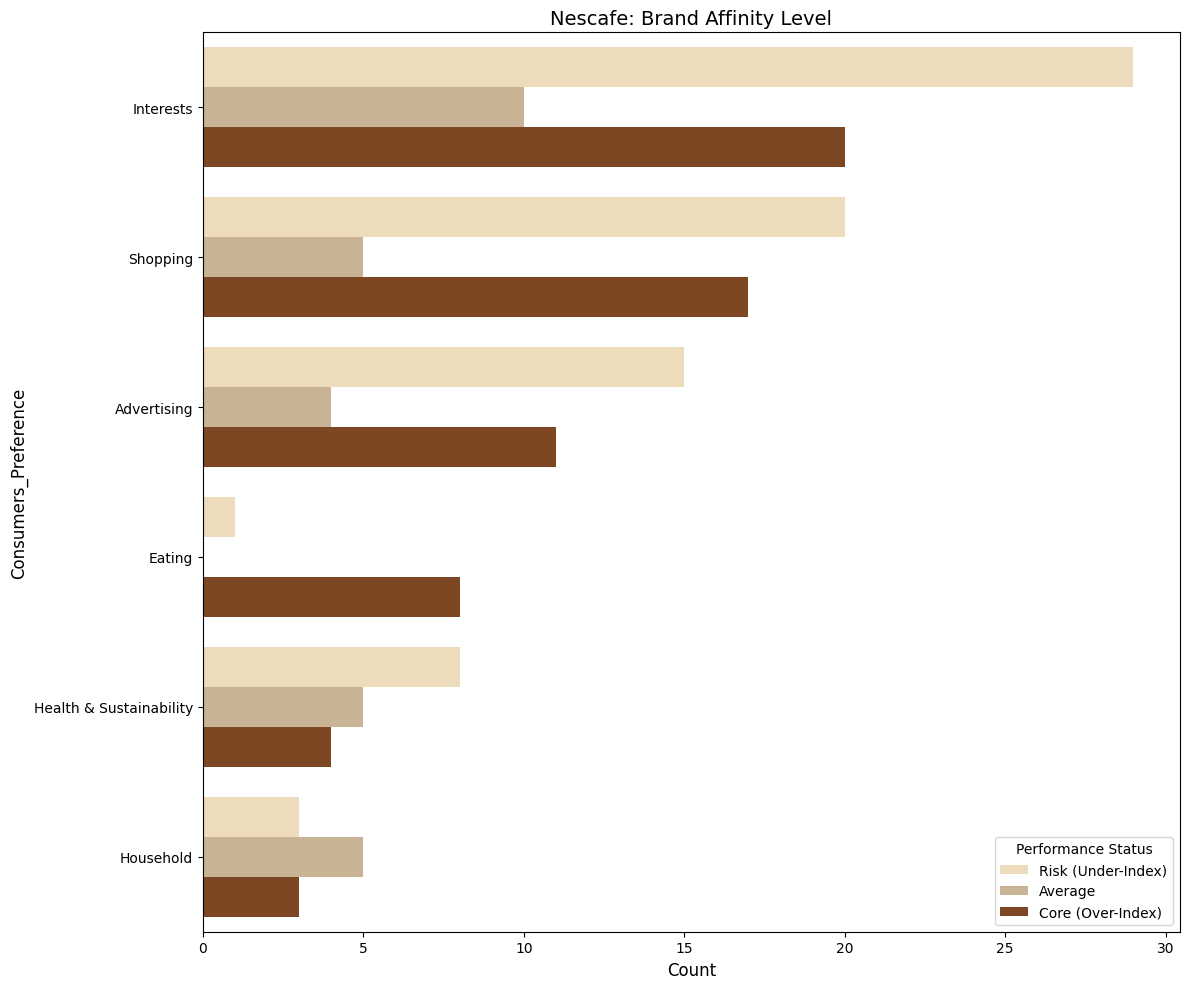

In [ ]:
order = df_pref[df_pref['Nescafe_Status'] == 'Core (Over-Index)']['Consumers_Preference'].value_counts().index
plt.figure(figsize=(12, 10))
sns.countplot(data=df_pref, y='Consumers_Preference', hue='Nescafe_Status', order=order, palette={'Core (Over-Index)': 'saddlebrown', 'Average': 'tan', 'Risk (Under-Index)': 'wheat'})
plt.xlabel('Count', fontsize=12)
plt.ylabel('Consumers_Preference', fontsize=12)
plt.title('Nescafe: Brand Affinity Level', fontsize=14)
plt.legend(title='Performance Status', loc='lower right')
plt.tight_layout()
plt.show()

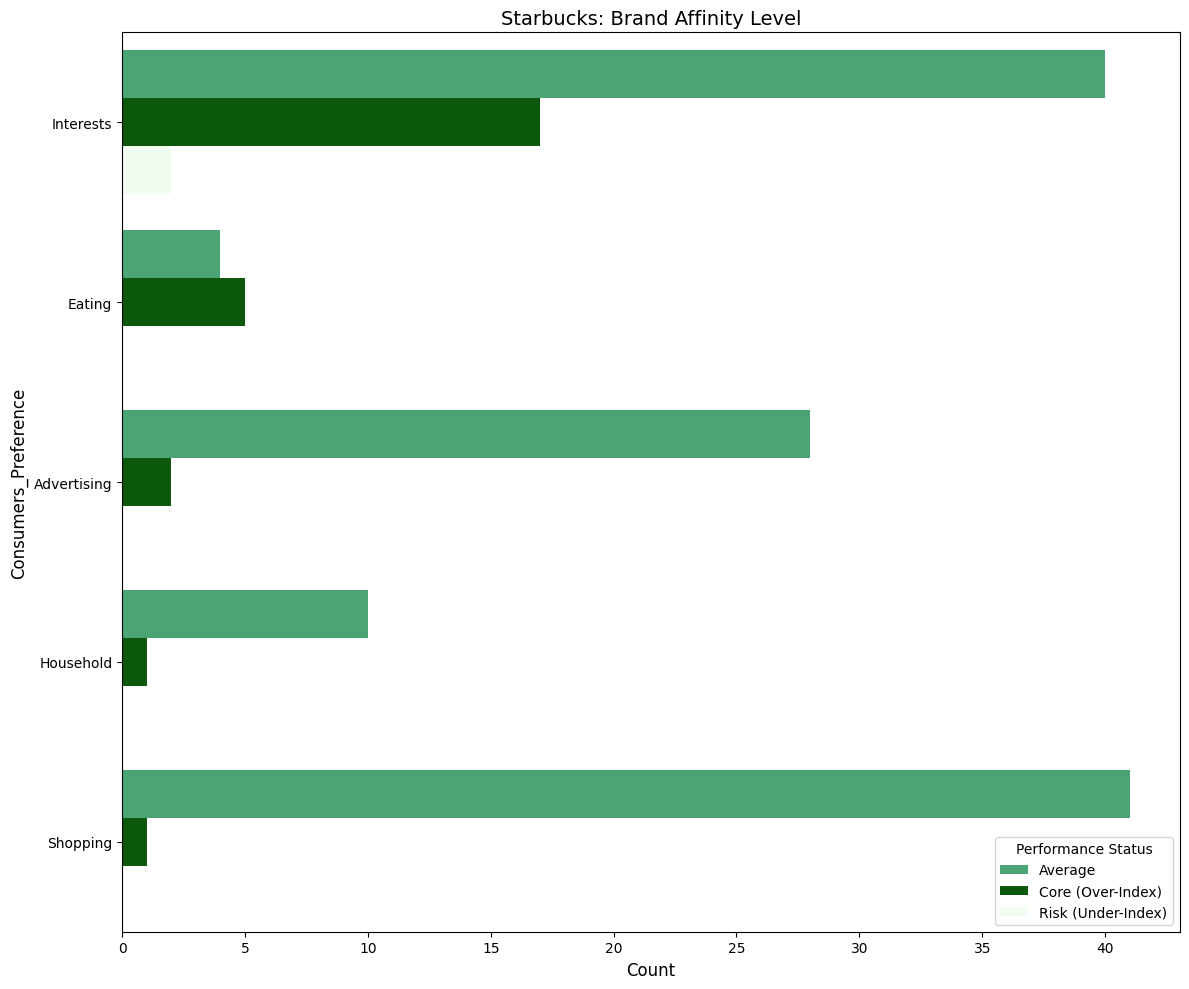

In [ ]:
order = df_pref[df_pref['Starbucks_Status'] == 'Core (Over-Index)']['Consumers_Preference'].value_counts().index
plt.figure(figsize=(12, 10))
sns.countplot(data=df_pref, y='Consumers_Preference', hue='Starbucks_Status',order=order, palette={'Core (Over-Index)': 'darkgreen', 'Average': 'mediumseagreen', 'Risk (Under-Index)': 'honeydew'})
plt.xlabel('Count', fontsize=12)
plt.ylabel('Consumers_Preference', fontsize=12)
plt.title('Starbucks: Brand Affinity Level', fontsize=14)
plt.legend(title='Performance Status', loc='lower right')
plt.tight_layout()
plt.show()

In [ ]:
print(df_pref['Header'].unique())

['Exposed Touchpoints' 'Most Influential Touchpoints'
 'Advertising Associations' 'Diets in the Household'
 'Actively Managing Health' 'Health & Wellness Attitudes'
 'Financial Attitudes' 'Hobbies' 'Activities'
 'Private Label General Perceptions' 'Shopping Attitudes'
 'Shopping Behavior' 'Online shopping is…' 'Online Shopping Attitudes'
 'Sports Fandom']


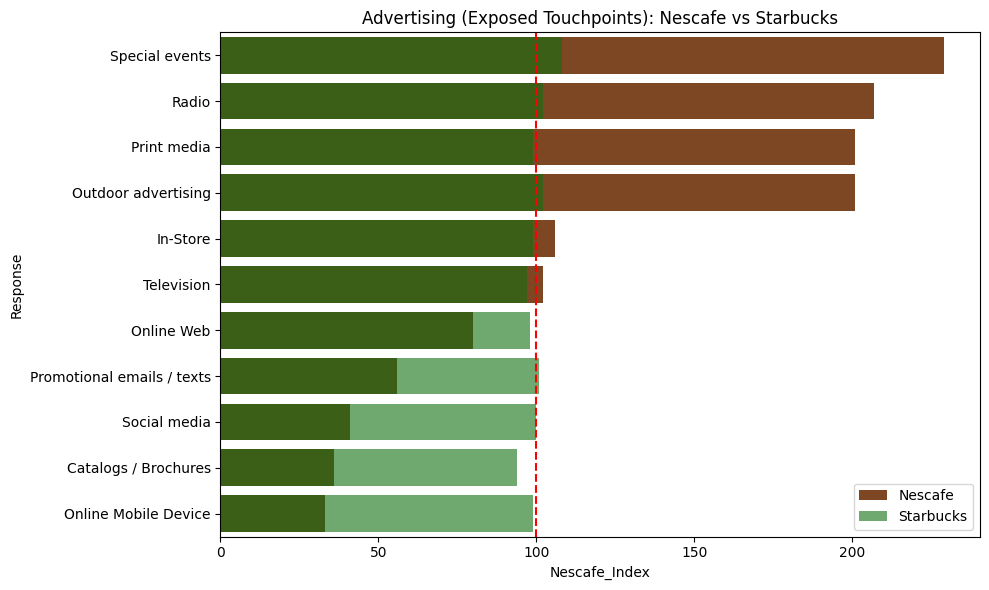

In [ ]:
adv_touchpts_data = df_pref[df_pref['Header'] == 'Exposed Touchpoints']
adv_touchpts_data = adv_touchpts_data.sort_values('Nescafe_Index', ascending=False)
plt.figure(figsize=(10, 6))
sns.barplot(data=adv_touchpts_data, x='Nescafe_Index', y='Response', color='saddlebrown', label='Nescafe')
sns.barplot(data=adv_touchpts_data, x='Starbucks_Index', y='Response', color='green', alpha=0.6, label='Starbucks')
plt.axvline(100, color='red', linestyle='--')
plt.title('Advertising (Exposed Touchpoints): Nescafe vs Starbucks')
plt.tight_layout()
plt.legend()
plt.show()

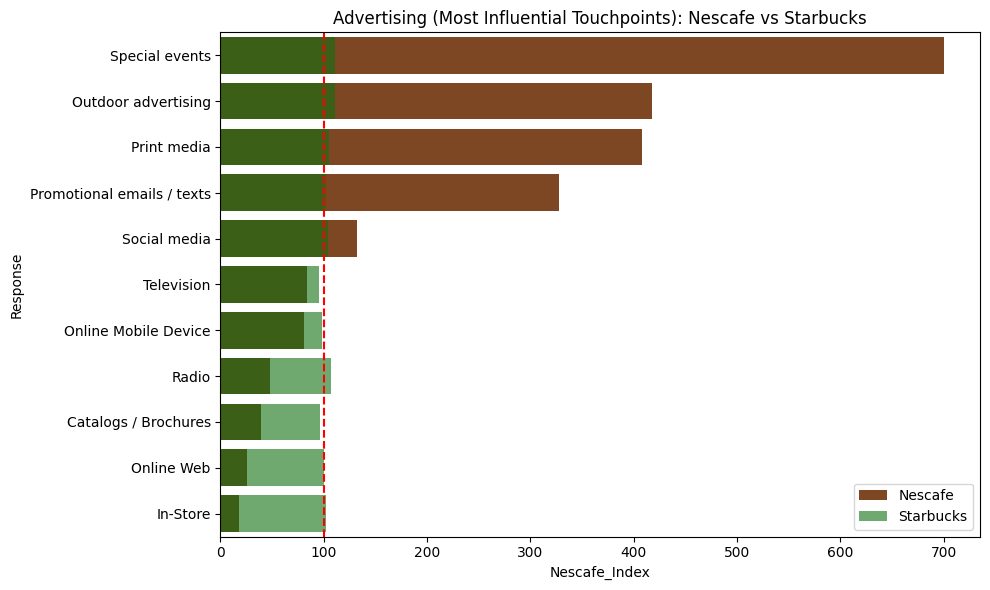

In [ ]:
adv_mostinf_data = df_pref[df_pref['Header'] == 'Most Influential Touchpoints']
adv_mostinf_data = adv_mostinf_data.sort_values('Nescafe_Index', ascending=False)
plt.figure(figsize=(10, 6))
sns.barplot(data=adv_mostinf_data, x='Nescafe_Index', y='Response', color='saddlebrown', label='Nescafe')
sns.barplot(data=adv_mostinf_data, x='Starbucks_Index', y='Response', color='green', alpha=0.6, label='Starbucks')
plt.axvline(100, color='red', linestyle='--')
plt.title('Advertising (Most Influential Touchpoints): Nescafe vs Starbucks')
plt.tight_layout()
plt.legend()
plt.show()

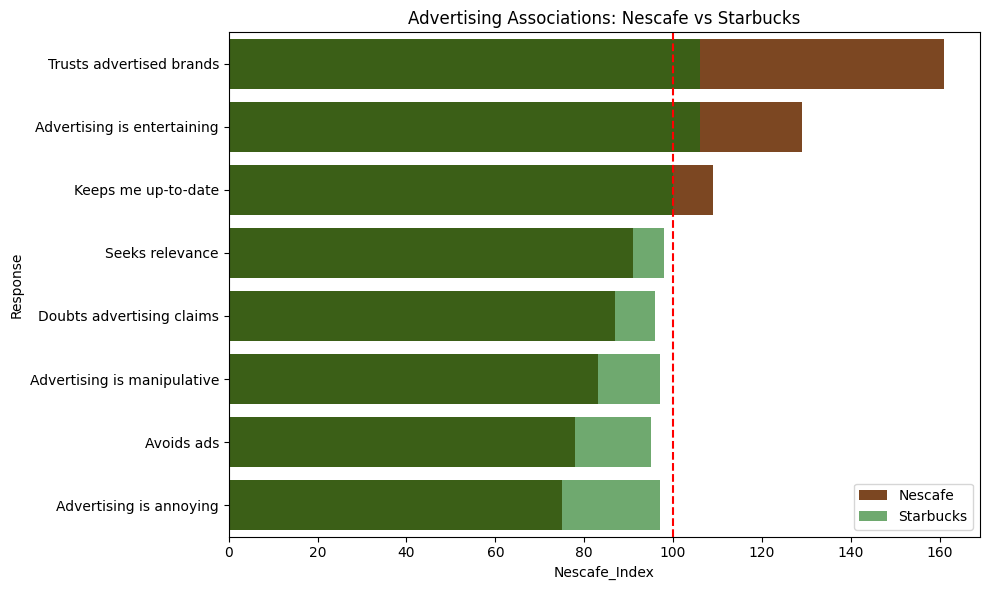

In [ ]:
adv_ass_data = df_pref[df_pref['Header'] == 'Advertising Associations']
adv_ass_data = adv_ass_data.sort_values('Nescafe_Index', ascending=False)
plt.figure(figsize=(10, 6))
sns.barplot(data=adv_ass_data, x='Nescafe_Index', y='Response', color='saddlebrown', label='Nescafe')
sns.barplot(data=adv_ass_data, x='Starbucks_Index', y='Response', color='green', alpha=0.6, label='Starbucks')
plt.axvline(100, color='red', linestyle='--')
plt.title('Advertising Associations: Nescafe vs Starbucks')
plt.tight_layout()
plt.legend()
plt.show()

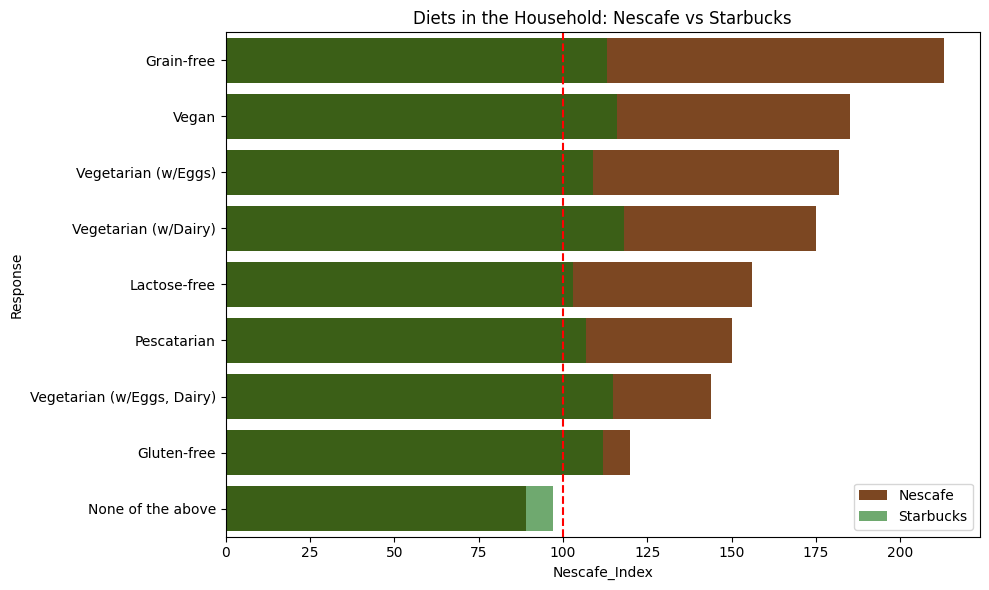

In [ ]:
eating_data = df_pref[df_pref['Header'] == 'Diets in the Household']
eating_data = eating_data.sort_values('Nescafe_Index', ascending=False)
plt.figure(figsize=(10, 6))
sns.barplot(data=eating_data, x='Nescafe_Index', y='Response', color='saddlebrown', label='Nescafe')
sns.barplot(data=eating_data, x='Starbucks_Index', y='Response', color='green', alpha=0.6, label='Starbucks')
plt.axvline(100, color='red', linestyle='--')
plt.title('Diets in the Household: Nescafe vs Starbucks')
plt.tight_layout()
plt.legend()
plt.show()

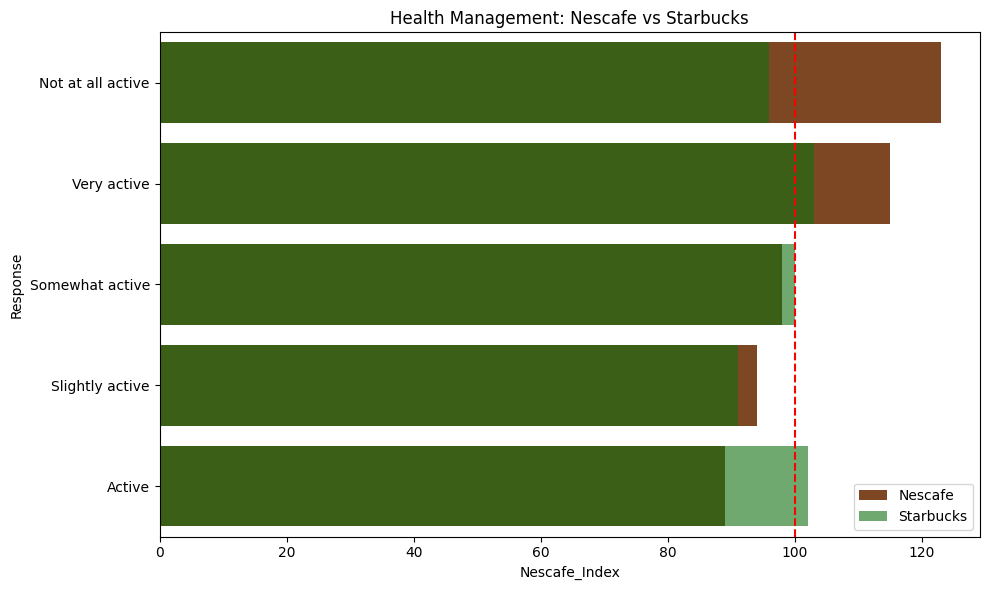

In [ ]:
health_data = df_pref[df_pref['Header'] == 'Actively Managing Health']
health_data = health_data.sort_values('Nescafe_Index', ascending=False)
plt.figure(figsize=(10, 6))
sns.barplot(data=health_data, x='Nescafe_Index', y='Response', color='saddlebrown', label='Nescafe')
sns.barplot(data=health_data, x='Starbucks_Index', y='Response', color='green', alpha=0.6, label='Starbucks')
plt.axvline(100, color='red', linestyle='--')
plt.title('Health Management: Nescafe vs Starbucks')
plt.tight_layout()
plt.legend()
plt.show()

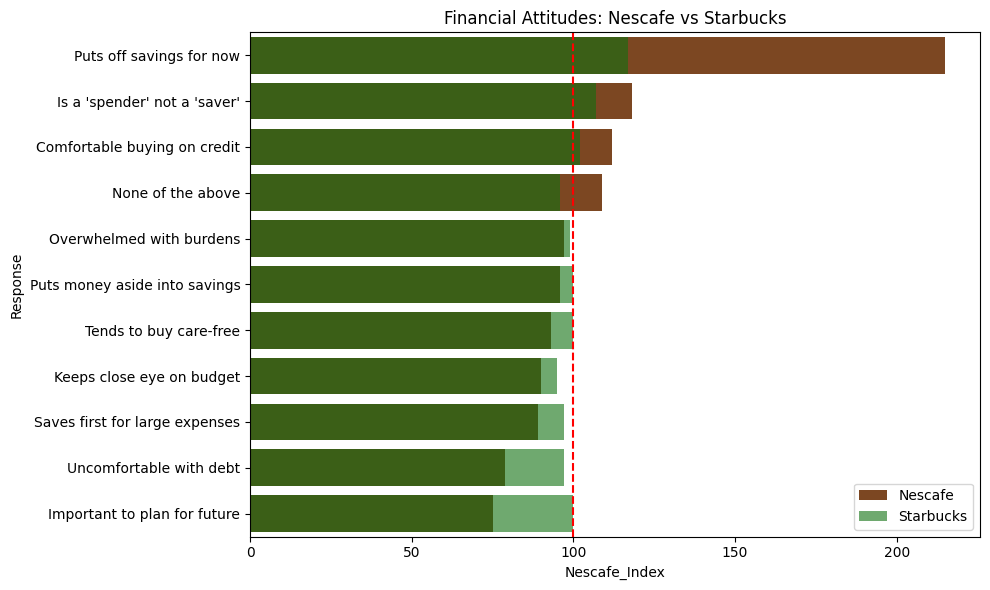

In [ ]:
household_data = df_pref[df_pref['Header'] == 'Financial Attitudes']
household_data = household_data.sort_values('Nescafe_Index', ascending=False)
plt.figure(figsize=(10, 6))
sns.barplot(data=household_data, x='Nescafe_Index', y='Response', color='saddlebrown', label='Nescafe')
sns.barplot(data=household_data, x='Starbucks_Index', y='Response', color='green', alpha=0.6, label='Starbucks')
plt.axvline(100, color='red', linestyle='--')
plt.title('Financial Attitudes: Nescafe vs Starbucks')
plt.tight_layout()
plt.legend()
plt.show()

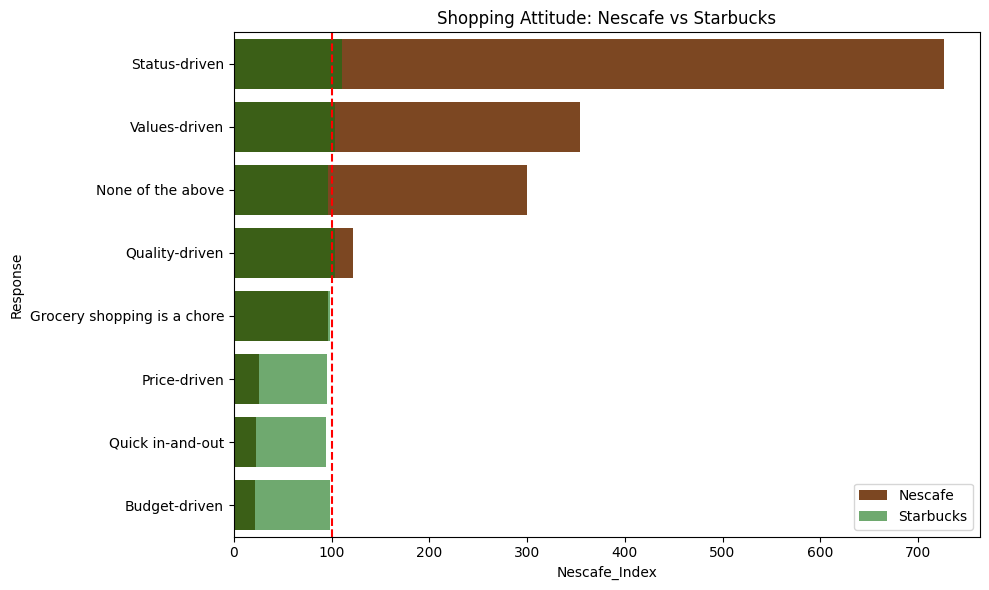

In [ ]:
shop_att_data = df_pref[df_pref['Header'] == 'Shopping Attitudes']
shop_att_data = shop_att_data.sort_values('Nescafe_Index', ascending=False)
plt.figure(figsize=(10, 6))
sns.barplot(data=shop_att_data, x='Nescafe_Index', y='Response', color='saddlebrown', label='Nescafe')
sns.barplot(data=shop_att_data, x='Starbucks_Index', y='Response', color='green', alpha=0.6, label='Starbucks')
plt.axvline(100, color='red', linestyle='--')
plt.title('Shopping Attitude: Nescafe vs Starbucks')
plt.tight_layout()
plt.legend()
plt.show()

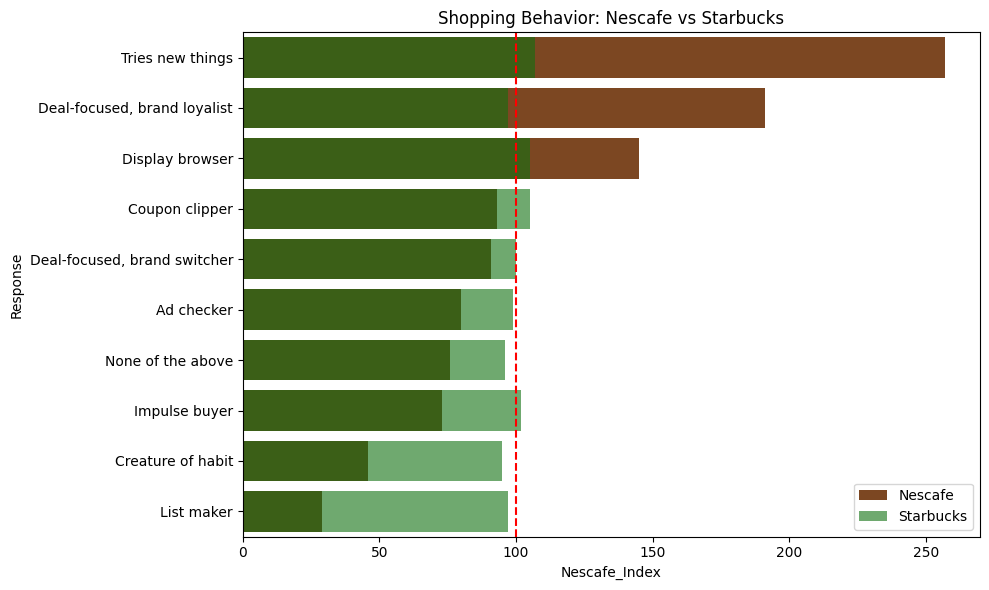

In [ ]:
shop_beh_data = df_pref[df_pref['Header'] == 'Shopping Behavior']
shop_beh_data = shop_beh_data.sort_values('Nescafe_Index', ascending=False)
plt.figure(figsize=(10, 6))
sns.barplot(data=shop_beh_data, x='Nescafe_Index', y='Response', color='saddlebrown', label='Nescafe')
sns.barplot(data=shop_beh_data, x='Starbucks_Index', y='Response', color='green', alpha=0.6, label='Starbucks')
plt.axvline(100, color='red', linestyle='--')
plt.title('Shopping Behavior: Nescafe vs Starbucks')
plt.tight_layout()
plt.legend()
plt.show()

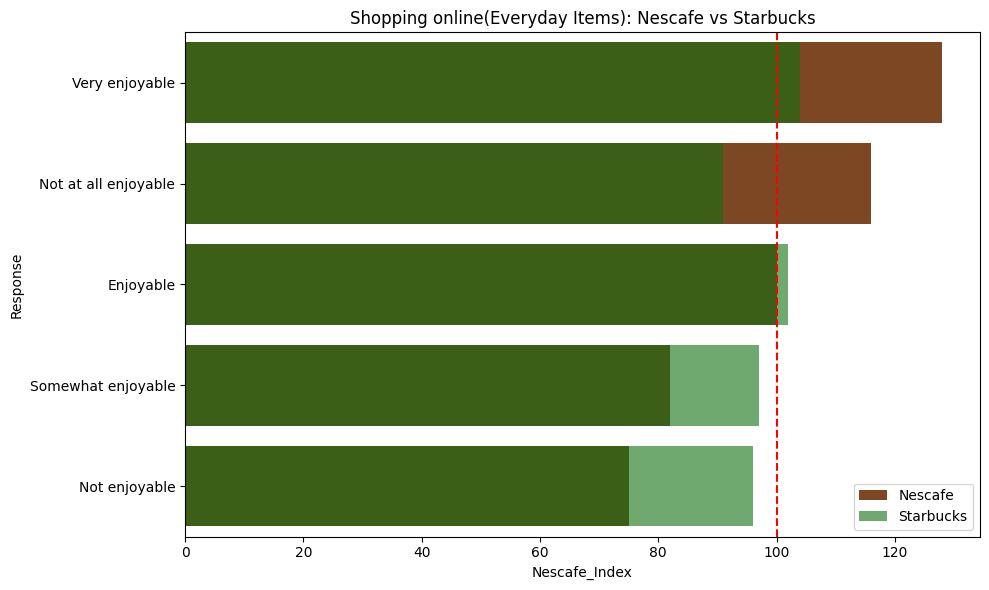

In [ ]:
online_shop_data = df_pref[df_pref['Header'] == 'Online shopping is…']
online_shop_data = online_shop_data.sort_values('Nescafe_Index', ascending=False)
plt.figure(figsize=(10, 6))
sns.barplot(data=online_shop_data, x='Nescafe_Index', y='Response', color='saddlebrown', label='Nescafe')
sns.barplot(data=online_shop_data, x='Starbucks_Index', y='Response', color='green', alpha=0.6, label='Starbucks')
plt.axvline(100, color='red', linestyle='--')
plt.title('Shopping online(Everyday Items): Nescafe vs Starbucks')
plt.tight_layout()
plt.legend()
plt.show()

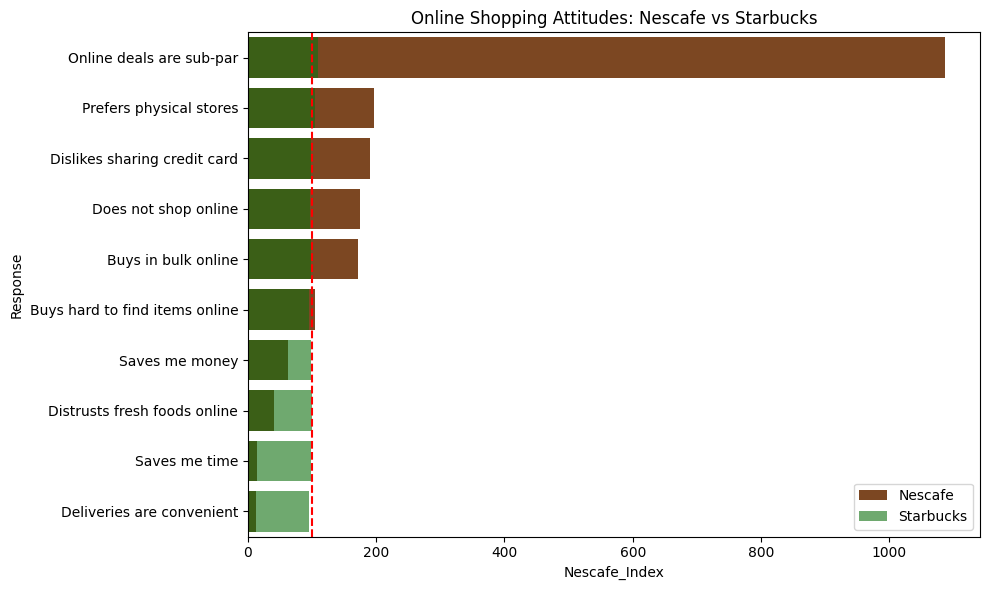

In [ ]:
online_shop_att_data = df_pref[df_pref['Header'] == 'Online Shopping Attitudes']
online_shop_att_data = online_shop_att_data.sort_values('Nescafe_Index', ascending=False)
plt.figure(figsize=(10, 6))
sns.barplot(data=online_shop_att_data, x='Nescafe_Index', y='Response', color='saddlebrown', label='Nescafe')
sns.barplot(data=online_shop_att_data, x='Starbucks_Index', y='Response', color='green', alpha=0.6, label='Starbucks')
plt.axvline(100, color='red', linestyle='--')
plt.title('Online Shopping Attitudes: Nescafe vs Starbucks')
plt.tight_layout()
plt.legend()
plt.show()

/tmp/ipykernel_459/1736072601.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


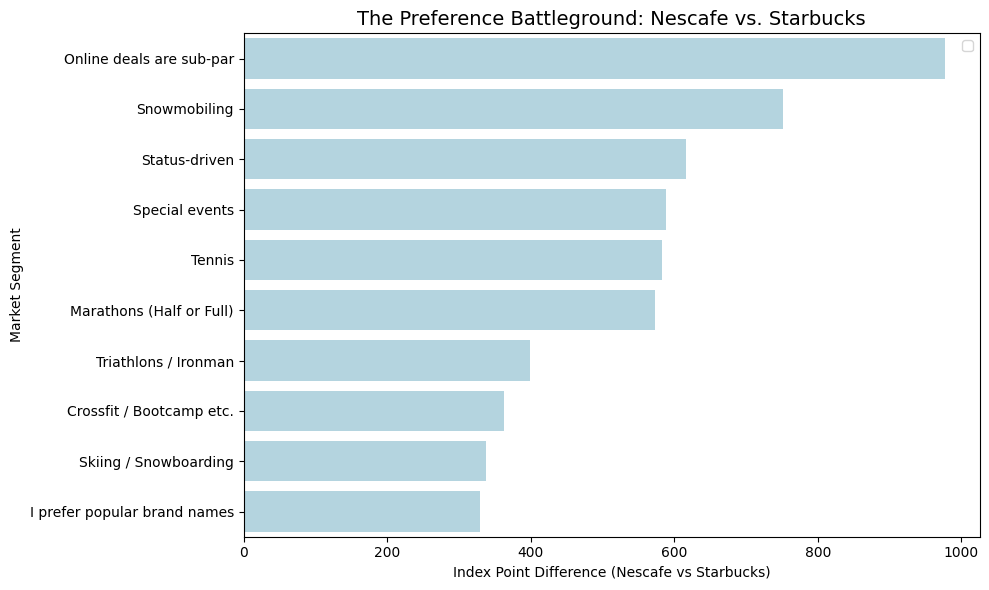

In [ ]:
gap_data = df_pref.sort_values('Index_Gap', ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(data=gap_data, x='Index_Gap', y='Response', color='lightblue')
plt.title('The Preference Battleground: Nescafe vs. Starbucks', fontsize=14)
plt.xlabel('Index Point Difference (Nescafe vs Starbucks)')
plt.ylabel('Market Segment')
plt.tight_layout()
plt.legend()
plt.show()

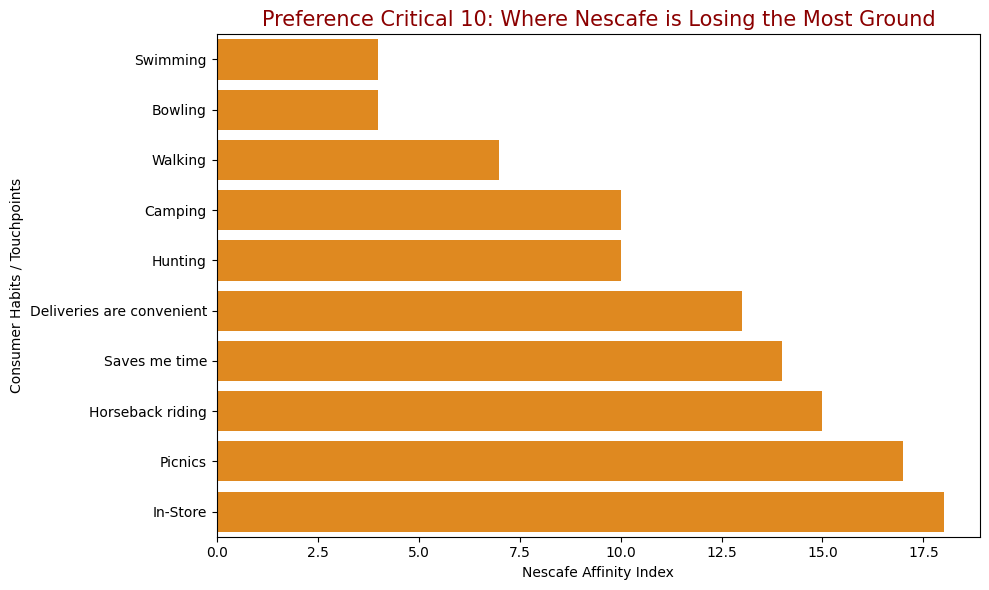

In [ ]:
# --- Critical Action List (Preference Data) ---
nescafe_risks = df_pref.sort_values('Nescafe_Index', ascending=True).head(10)
plt.figure(figsize=(10, 6))
sns.barplot(data=nescafe_risks, x='Nescafe_Index', y='Response', color='darkorange')
plt.title('Preference Critical 10: Where Nescafe is Losing the Most Ground', fontsize=15, color='darkred')
plt.xlabel('Nescafe Affinity Index')
plt.ylabel('Consumer Habits / Touchpoints')
plt.tight_layout()
plt.show()

**Nescafe Strategic Summary: Key Performance Indicators**

*  **YOUTH DOMINANCE:** Nescafe maintains a massive competitive lead in   the 18-20 age bracket and among Gen Z consumers.
*  **LARGE HOUSEHOLD STAPLE:** The brand is the clear favorite for large families, with the widest competitive gaps found in households of 6 to 7+ people.
*  **PHYSICAL MARKETING IMPACT**: Nescafe's success is driven by real-world presence, specifically through Special Events and Outdoor Advertising.
*  **THE STATUS PARADOX:** Loyalists are not price-motivated; they are overwhelmingly Status-driven and Values-driven, viewing the brand as a symbol of quality.
*  **DIETARY VERSATILITY:** The brand leads heavily in households following specialized diets, including Grain-free and Vegan lifestyles.
*  **EDUCATIONAL GAP:** Nescafe currently trails Starbucks among consumers with 4-year College and Graduate Degrees
*  **Digital Skepticism:** Core consumers are highly skeptical of online retail, with a dominant belief that "Online deals are sub-par".
*   **In-Store Vulnerability:** The brand's "In-Store" experience affinity is significantly below average, indicating a need for better retail engagement.
*   **DEMOGRAPHIC OPPORTUNITIES:** The largest untapped growth segments remain the Retired and 65+ populations.







